# Notebook 06 — Exploratory Data Analysis & Quality Report

**Purpose:**  
Comprehensive view of the final processed dataset. Read-only — does not modify any files.

**Inputs** (`data/processed/`):
- `final_bid_data.xlsx`
- `final_FE.xlsx`
- `company_info.xlsx`
- `final_competitor_analysis.xlsx`

**Sections:**
1. Data Quality Report
2. Temporal Trends
3. Portal & Ministry Distribution
4. Tender Value Distribution
5. State-wise Distribution
6. Competitive Landscape
7. Drilling Activity & Per-Meter Rate
8. Mineral Distribution
9. Power BI Dashboard Reference

---

## 1. Imports & Setup

In [12]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from config import PROCESSED_FILES, FOCUS_COMPANY_ABBR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

print('Setup complete.')

Setup complete.


## 2. Load Final Datasets

In [13]:
bid_data            = pd.read_excel(PROCESSED_FILES['featured_bids'])
financial_eval      = pd.read_excel(PROCESSED_FILES['final_fe'])
company_info        = pd.read_excel(PROCESSED_FILES['company_info'])
competitor_analysis = pd.read_excel(PROCESSED_FILES['competitor_analysis'])

for df in [bid_data, financial_eval, company_info, competitor_analysis]:
    df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

if bid_data.index.name == 'bid_number':
    bid_data = bid_data.reset_index()
if financial_eval.index.name == 'financial_eval_id':
    financial_eval = financial_eval.reset_index()

bid_data['bid_start_date'] = pd.to_datetime(bid_data['bid_start_date'], errors='coerce')
bid_data['bid_year']       = bid_data['bid_start_date'].dt.year

print(f"bid_data            : {bid_data.shape}")
print(f"financial_eval      : {financial_eval.shape}")
print(f"company_info        : {company_info.shape}")
print(f"competitor_analysis : {competitor_analysis.shape}")

bid_data            : (5689, 17)
financial_eval      : (29181, 12)
company_info        : (6832, 5)
competitor_analysis : (6813, 11)


## 3. Data Quality Report

In [14]:
quality = pd.DataFrame({
    'non_null'        : bid_data.notna().sum(),
    'missing'         : bid_data.isna().sum(),
    'completeness_pct': (bid_data.notna().mean() * 100).round(1),
    'dtype'           : bid_data.dtypes,
}).sort_values('completeness_pct')

print(f"Data Quality Report — final bid_data  ({len(bid_data)} rows)")
print("=" * 55)
print(quality.to_string())

Data Quality Report — final bid_data  (5689 rows)
                   non_null  missing  completeness_pct           dtype
drilling_meterage       718     4971              12.6         float64
mineral_name           1536     4153              27.0          object
state_name             1819     3870              32.0          object
contract_period        3175     2514              55.8         float64
work_order             3223     2466              56.7          object
award_status           5502      187              96.7          object
winning_price          5638       51              99.1         float64
winner                 5638       51              99.1          object
tender_value           5681        8              99.9         float64
website_name           5689        0             100.0          object
bid_number             5689        0             100.0          object
bid_start_date         5689        0             100.0  datetime64[ns]
department_org         5689

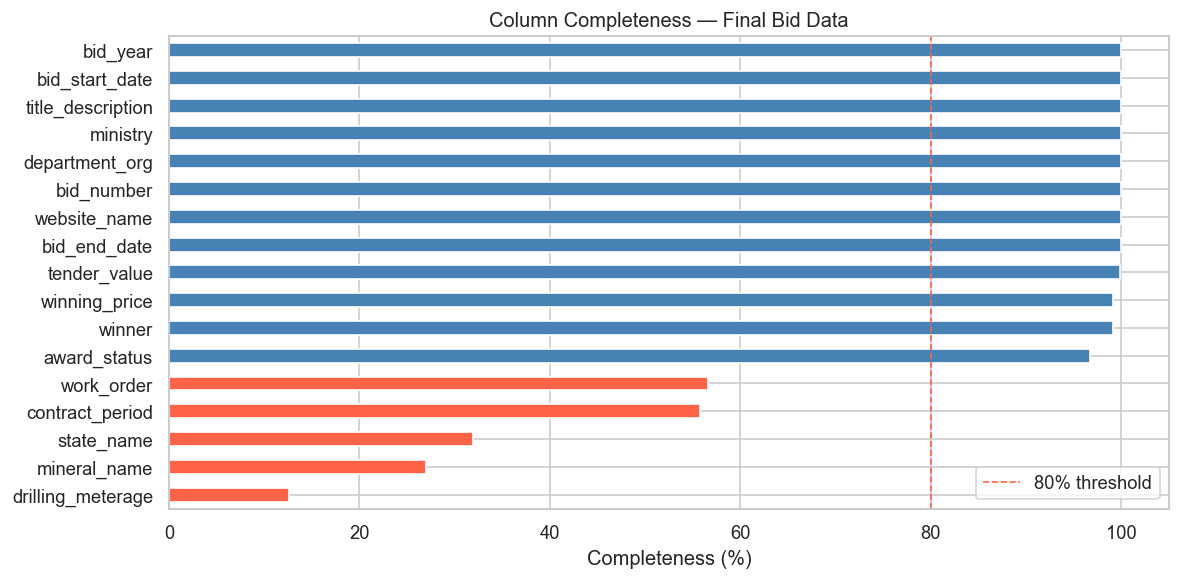

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
completeness = (bid_data.notna().mean() * 100).sort_values()
colors = ['tomato' if v < 80 else 'steelblue' for v in completeness]
completeness.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=80, color='tomato', linestyle='--', linewidth=1, label='80% threshold')
ax.set_xlabel('Completeness (%)')
ax.set_title('Column Completeness — Final Bid Data')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Tender Volume Over Time

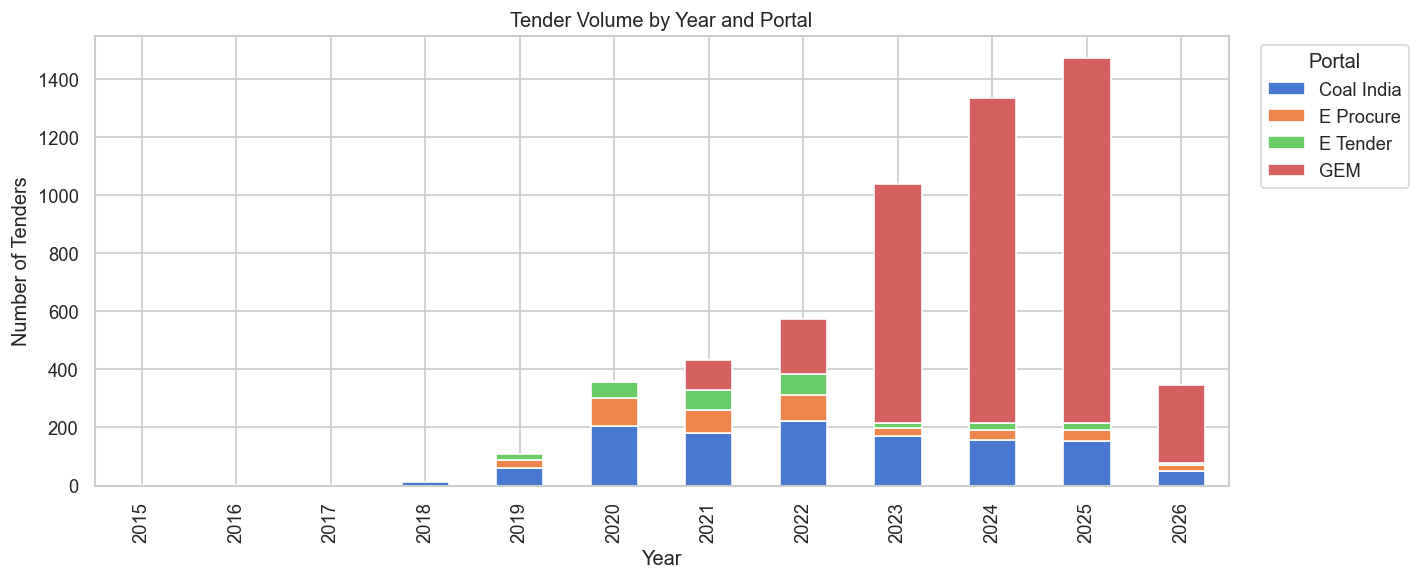


Annual tender volume:
website_name  Coal India  E Procure  E Tender   GEM
bid_year                                           
2015                   1          0         0     0
2016                   2          0         0     0
2017                   3          0         0     0
2018                  13          0         0     0
2019                  59         30        21     0
2020                 205         97        56     3
2021                 181         79        69   105
2022                 222         91        72   187
2023                 172         26        18   822
2024                 158         33        26  1117
2025                 153         37        24  1260
2026                  51         21         6   269


In [16]:
annual = (
    bid_data.groupby(['bid_year', 'website_name'])
    .size()
    .unstack(fill_value=0)
)
annual.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Tender Volume by Year and Portal')
plt.xlabel('Year')
plt.ylabel('Number of Tenders')
plt.legend(title='Portal', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\nAnnual tender volume:")
print(annual.to_string())

## 5. Portal & Ministry Distribution

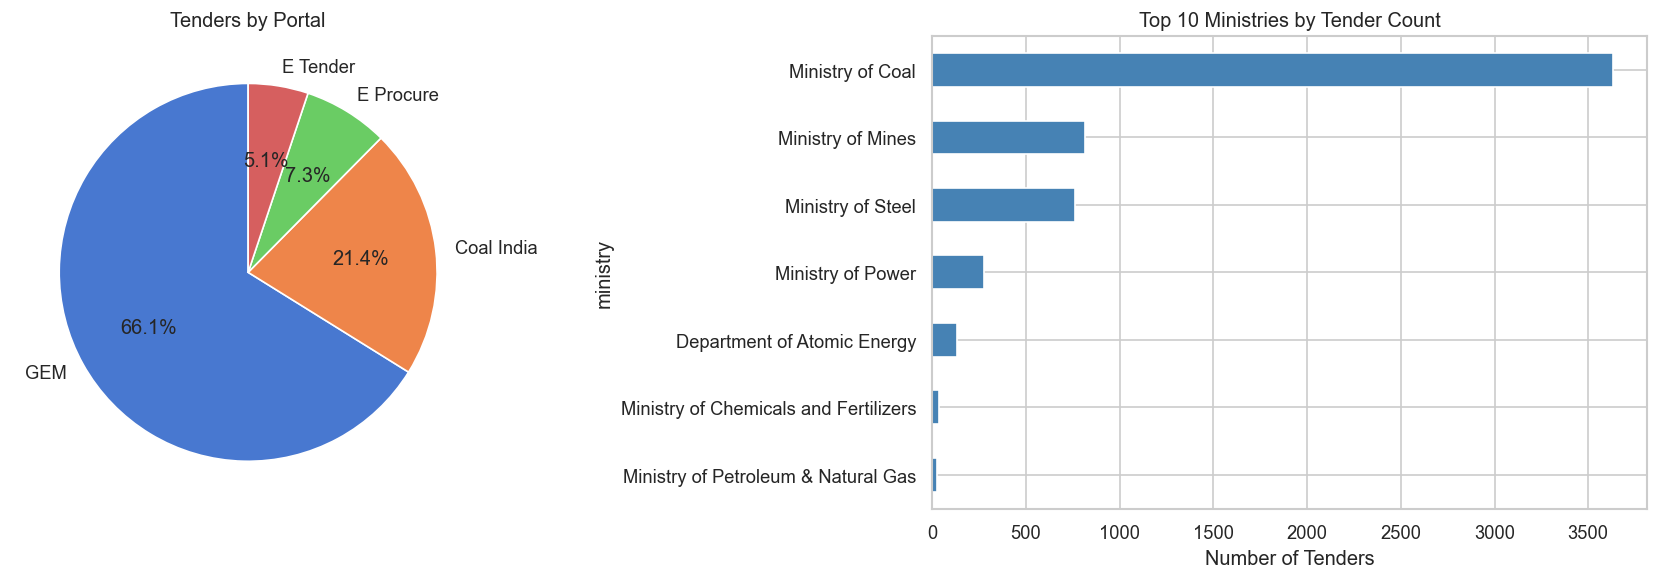

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

portal_counts = bid_data['website_name'].value_counts()
portal_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[0], startangle=90)
axes[0].set_title('Tenders by Portal')
axes[0].set_ylabel('')

ministry_counts = bid_data['ministry'].value_counts().head(10)
ministry_counts.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Ministries by Tender Count')
axes[1].set_xlabel('Number of Tenders')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Tender Value Distribution

C:\Users\Sakshi\AppData\Local\Temp\ipykernel_22804\4128107413.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
C:\Users\Sakshi\AppData\Local\Temp\ipykernel_22804\4128107413.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
C:\Users\Sakshi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Sakshi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


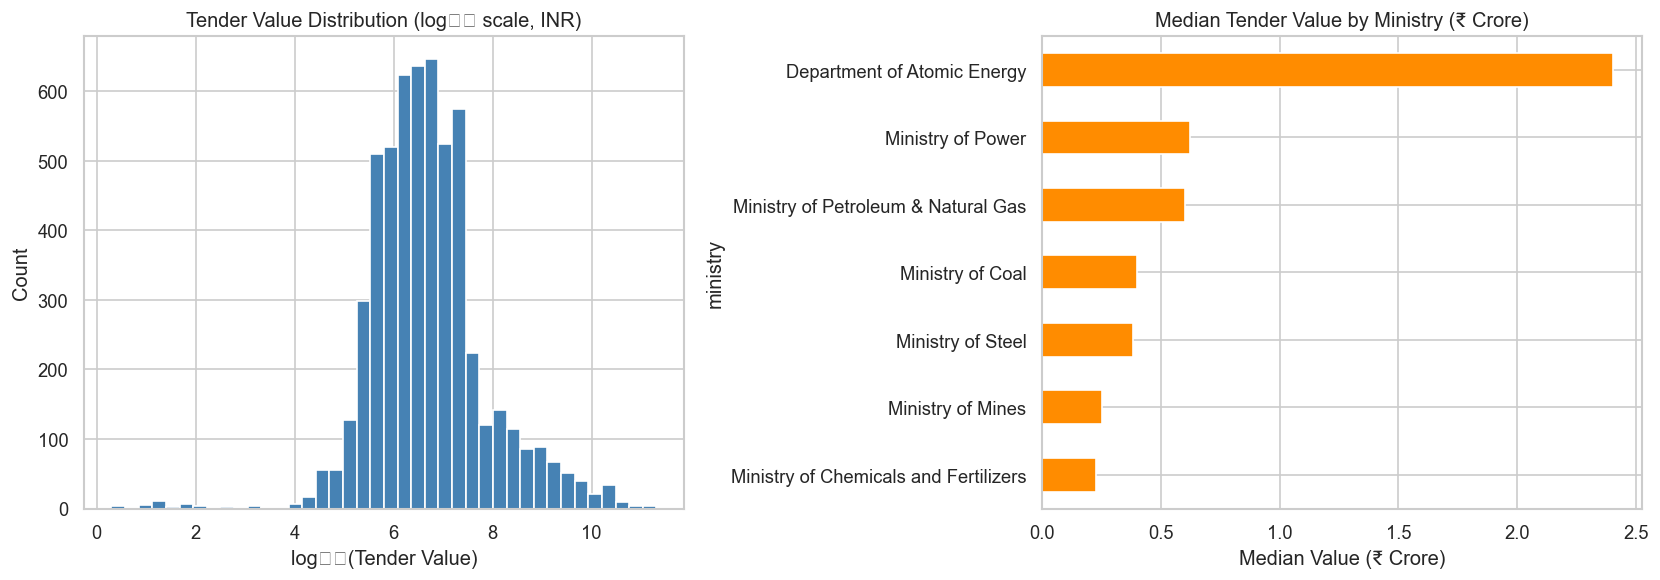


Tender Value Summary (INR):
count              5,681
mean         527,597,928
std        5,240,768,117
min                    0
25%              879,789
50%            3,950,803
75%           17,885,000
max      204,020,400,000


In [18]:
value_data = bid_data['tender_value'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_vals = np.log10(value_data[value_data > 0] + 1)
axes[0].hist(log_vals, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Tender Value Distribution (log₁₀ scale, INR)')
axes[0].set_xlabel('log₁₀(Tender Value)')
axes[0].set_ylabel('Count')

median_val = (
    bid_data.groupby('ministry')['tender_value']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .div(1e7)
)
median_val.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Median Tender Value by Ministry (₹ Crore)')
axes[1].set_xlabel('Median Value (₹ Crore)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print("\nTender Value Summary (INR):")
print(value_data.describe().apply(lambda x: f'{x:,.0f}').to_string())

## 7. Award Rate by Portal

In [19]:
award_rate = (
    bid_data.groupby('website_name')
    .agg(
        total_bids=('bid_number', 'count'),
        awarded   =('winner', lambda x: x.notna().sum()),
    )
    .assign(award_rate_pct=lambda d: (d['awarded'] / d['total_bids'] * 100).round(1))
)
print("Award Rate by Portal:")
print(award_rate.to_string())

Award Rate by Portal:
              total_bids  awarded  award_rate_pct
website_name                                     
Coal India          1220     1220           100.0
E Procure            414      414           100.0
E Tender             292      291            99.7
GEM                 3763     3713            98.7


## 8. State-wise Distribution

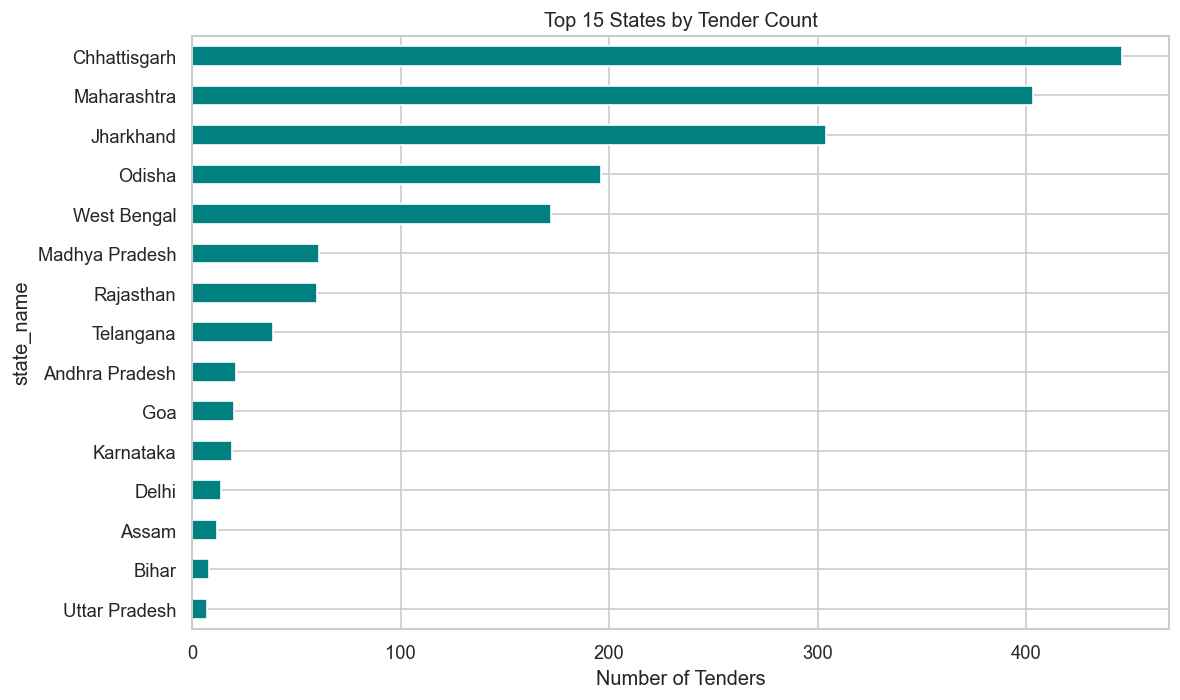

In [20]:
state_counts = bid_data['state_name'].value_counts().head(15)
state_counts.plot(kind='barh', figsize=(10, 6), color='teal')
plt.title('Top 15 States by Tender Count')
plt.xlabel('Number of Tenders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Competitive Landscape

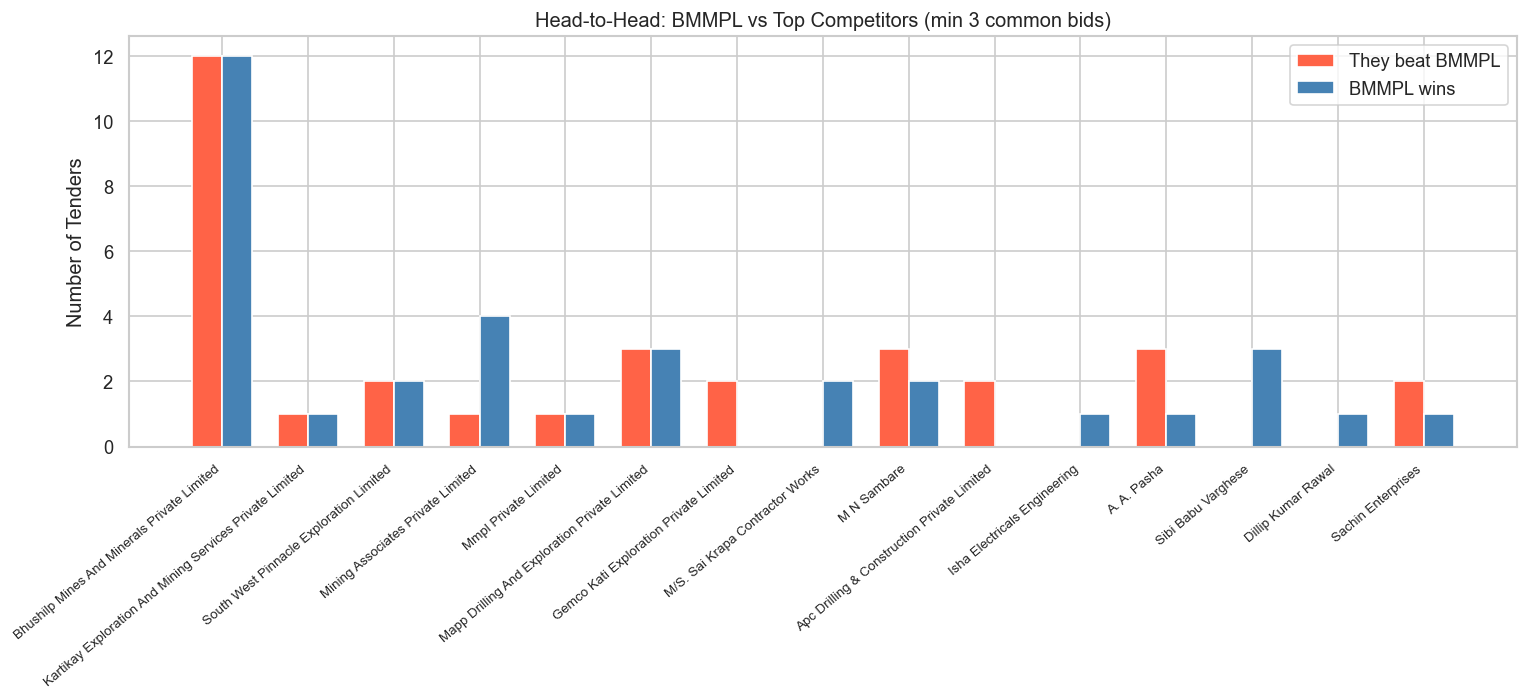

In [21]:
abbr        = FOCUS_COMPANY_ABBR
common_col  = f'Common Bids with {abbr}'
won_col     = f'Bids Won Against {abbr}'
lost_col    = f'Bids Lost Against {abbr}'

head_to_head = (
    competitor_analysis[competitor_analysis[common_col] >= 3]
    .nlargest(15, common_col)
)

if not head_to_head.empty:
    fig, ax = plt.subplots(figsize=(13, 6))
    x, w   = range(len(head_to_head)), 0.35
    ax.bar([i - w/2 for i in x], head_to_head[won_col],  w, label=f'They beat {abbr}', color='tomato')
    ax.bar([i + w/2 for i in x], head_to_head[lost_col], w, label=f'{abbr} wins',       color='steelblue')
    ax.set_xticks(list(x))
    ax.set_xticklabels(head_to_head['Seller'], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Number of Tenders')
    ax.set_title(f'Head-to-Head: {abbr} vs Top Competitors (min 3 common bids)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"No companies found with 3+ common bids with {abbr}.")

## 10. Drilling Activity & Per-Meter Rate

C:\Users\Sakshi\AppData\Local\Temp\ipykernel_22804\2565156911.py:16: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
C:\Users\Sakshi\AppData\Local\Temp\ipykernel_22804\2565156911.py:16: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
C:\Users\Sakshi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Sakshi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


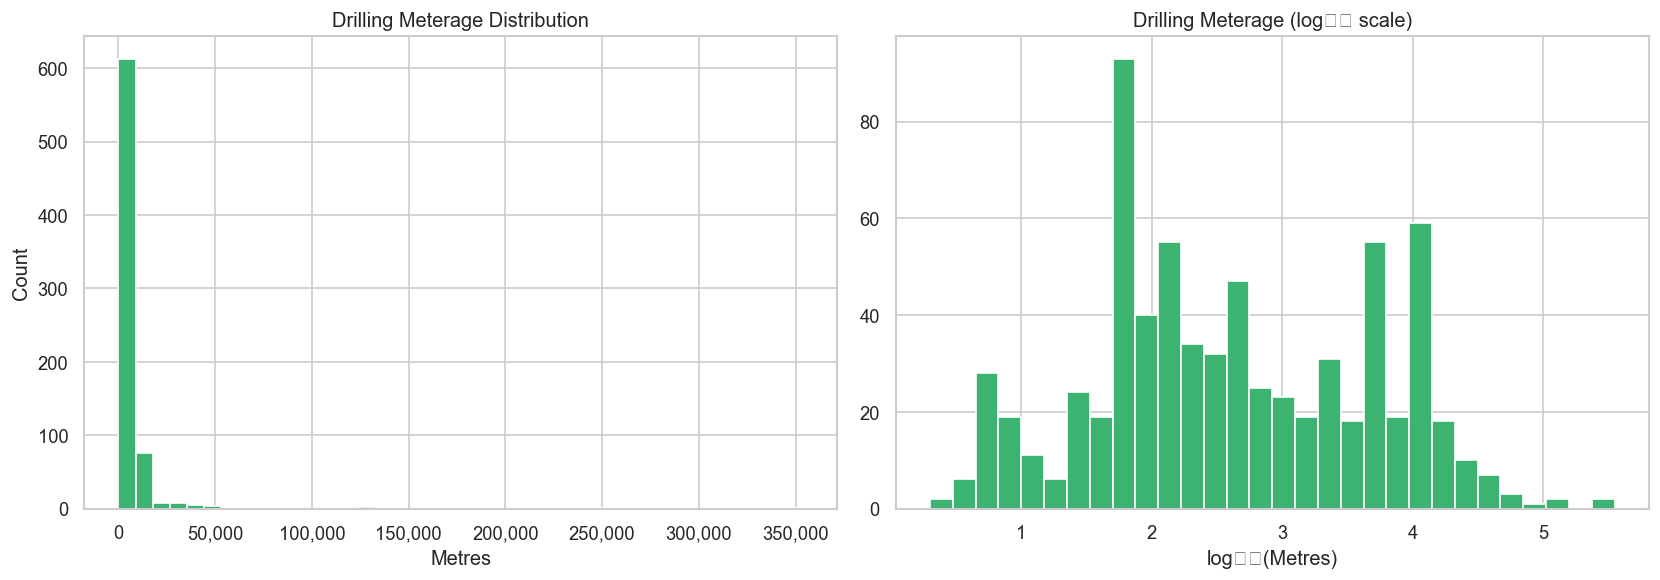


Drilling Meterage Summary:
count        718
mean       4,524
std       18,813
min            0
25%           50
50%          300
75%        3,950
max      353,800


ValueError: supplied range of [0.0008677215312269133, inf] is not finite

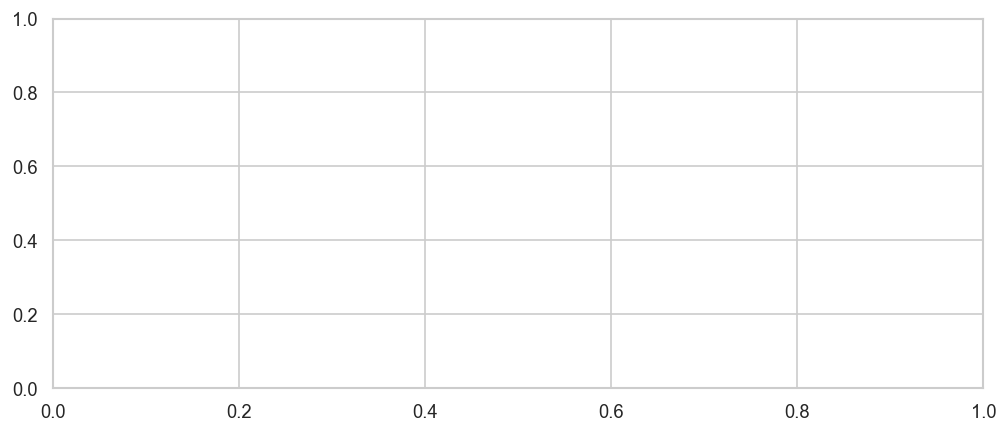

In [22]:
drilling = bid_data['drilling_meterage'].dropna()

if len(drilling) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(drilling, bins=40, color='mediumseagreen', edgecolor='white')
    axes[0].set_title('Drilling Meterage Distribution')
    axes[0].set_xlabel('Metres')
    axes[0].set_ylabel('Count')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    axes[1].hist(np.log10(drilling[drilling > 0] + 1), bins=30, color='mediumseagreen', edgecolor='white')
    axes[1].set_title('Drilling Meterage (log₁₀ scale)')
    axes[1].set_xlabel('log₁₀(Metres)')

    plt.tight_layout()
    plt.show()

    print("\nDrilling Meterage Summary:")
    print(drilling.describe().apply(lambda x: f'{x:,.0f}').to_string())

# Per-meter rate distribution (from financial_eval)
pmr = financial_eval['per_meter_rate'].dropna()
if len(pmr) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(np.log10(pmr[pmr > 0] + 1), bins=40, color='darkorchid', edgecolor='white')
    ax.set_title('Per-Meter Rate Distribution (log₁₀ scale, INR/m)')
    ax.set_xlabel('log₁₀(Per-Meter Rate)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    print("\nPer-Meter Rate Summary (INR/m):")
    print(pmr.describe().apply(lambda x: f'{x:,.2f}').to_string())

## 11. Mineral Distribution

In [ ]:
mineral_counts = bid_data['mineral_name'].value_counts()

if len(mineral_counts) > 0:
    mineral_counts.plot(kind='barh', figsize=(8, 5), color='goldenrod')
    plt.title('Tenders by Mineral Type')
    plt.xlabel('Number of Tenders')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("\nMineral distribution:")
    print(mineral_counts.to_string())

## 12. Power BI Dashboard Reference

The charts above are the Python-reproducible analytical layer. The full interactive
dashboard with dropdown filters and drill-through pages lives in the internal
Power BI report (MTIS Dashboard).

| Dashboard Page | What it shows | Corresponding section above |
|----------------|---------------|-----------------------------|
| Keyword Bid Explorer | All tenders for a free-text keyword; winner + price | Quality report |
| Keyword Summary | Bid count, tender value, bids over time, ministry split | Sections 4, 5 |
| Bid Detail | Single-tender drill-through with all participants ranked | Notebook 04 (financial_eval) |
| Ministry Overview | Bids, value, top winners per ministry (2019–2026) | Sections 4, 5 |
| Company Profile — Activity | Win history, revenue trend for any company | Notebook 05 |
| Company Profile — Pricing | Avg price, margin %, win rate, per-meter rate | Section 10, Notebook 05 |
| Competitive Bid Overview | Head-to-head KPIs + proportional bar vs BMMPL | Section 9 |

> The dashboard reads `final_bid_data.xlsx`, `final_FE.xlsx`, `company_info.xlsx`,
> and `final_competitor_analysis.xlsx` from `data/processed/`. Re-running the pipeline
> and refreshing the Power BI data source updates all visuals automatically.